In [2]:
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Any, Dict, List, Tuple

from comcatalyst.utils import calc_convergence_iter_bo

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## **Functions.**

In [ ]:
def load_results_from_json(json_path: str) -> List[dict]:
    return json.loads(Path(json_path).read_text())

def load_results_from_dir(dir_path: str) -> List[dict]:
    results = []
    for json_path in Path(dir_path).rglob("*.json"):
        data = load_results_from_json(json_path=json_path)
        results.extend(data)
    return results

In [ ]:
def filter_results_by_hyperparams(results, filters):
    filtered = []
    for r in results:
        match = all(
            float(r["hyperparams"].get(k, None)) == float(v)
            if isinstance(v, (int, float))
            else str(r["hyperparams"].get(k)) == str(v)
            for k, v in filters.items()
        )
        if match:
            filtered.append(r)
    return filtered

In [ ]:
def filter_results_by_x_opt(
    results: List[dict],
    x_opt_filters: dict,
) -> List[dict]:
    """
    Parameters
    ----------
    x_opt_filters : dict
        e.g. {0: 0, 1: 1} pour x_opt[0]=0 et x_opt[1]=1.
    """
    filtered = []
    for r in results:
        x_opt = r["x_opt"]
        match = all(
            x_opt[idx] == val
            for idx, val in x_opt_filters.items()
        )
        if match:
            filtered.append(r)
    return filtered

In [ ]:
def plot_convergence_curve(
    results: List[dict],
    metric: str, # y_data ou y_true_at_x_data
    filters: dict = None,
    figsize: tuple = (10, 5),
    ylim: Tuple[float, float] = (None, None),
    title: str = None,
    save_path: str = None,
) -> None:
    if filters:
        results = filter_results_by_hyperparams(results, filters)

    if not results:
        print("No results found after filter was applied.")
        return

    n_init = results[0]["hyperparams"]["n_init"]
    n_pts  = min(len(r[metric]) for r in results) # longueur minimale commune
    
    # pour chaque run, calculer la courbe
    all_curves = []
    for r in results:
        y = np.array(r[metric]).ravel()[:n_pts]
        y_best = np.maximum.accumulate(y) # meilleur y jusqu'a chaque iteration
        all_curves.append(y_best)

    all_curves = np.array(all_curves) # shape (n_runs, n_pts)
    mean = all_curves.mean(axis=0)
    std = all_curves.std(axis=0)
    lo = all_curves.min(axis=0)
    hi = all_curves.max(axis=0)
    iters = np.arange(1, n_pts + 1)

    fig, ax = plt.subplots(figsize=figsize)

    # courbe par run en transparence
    for curve in all_curves:
        ax.plot(iters, curve, color="gray", lw=0.8, alpha=0.2)

    # mean
    ax.plot(iters, mean, color="blue", lw=2, label="mean")
    # std
    ax.fill_between(iters, mean - std, mean + std, alpha=0.2, color="blue", label="std")
    # min / max
    ax.fill_between(iters, lo, hi, alpha=0.1, color="blue", label="[min, max]")

    # separation DoE / BO
    ax.axvspan(1, n_init, alpha=0.07, color="orange", label="DoE")
    ax.axvspan(n_init, n_pts, alpha=0.07, color="green", label="BO")
    ax.axvline(n_init, color="black", ls="--", lw=1)

    # true max
    ax.axhline(results[0]["y_true_max"], color="red", ls="--", lw=1)

    if title is None:
        filter_str = ", ".join(f"{k}={v}" for k, v in (filters or {}).items())
        title = f"{metric}" + (f" | {filter_str}" if filter_str else "")

    ax.set_xlabel("iterations")
    ax.set_ylabel("y_best")
    ax.set_ylim(bottom=ylim[0], top=ylim[1])
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

In [ ]:
def plot_boxplot(
    results: List[dict],
    metric: str,
    group_by: str,
    filters: Dict[str, Any] = None,
    figsize: Tuple[int, int] = (7, 5),
    ylim: Tuple[float, float] = (None, None),
    title: str = None,
    save_path: str = None,
) -> None:

    if filters:
        results = filter_results_by_hyperparams(results, filters)

    if not results:
        print("No results found after filter was applied.")
        return
        
    # grouper par valeur de group_by
    groups = {}
    for r in results:
        val = r["hyperparams"].get(group_by)
        if val is None:
            continue
        key = str(val)
        if key not in groups:
            groups[key] = []
        groups[key].append(r[metric])

    # trier les groupes par valeur
    try:
        sorted_keys = sorted(groups.keys(), key=lambda x: float(x))
    except ValueError:
        sorted_keys = sorted(groups.keys())

    data   = [groups[k] for k in sorted_keys]
    labels = [f"{k}" for k in sorted_keys]
    labels = [f"{k}\n(tot={len(groups[k])})" for k in sorted_keys]
    
    if title is None:
        filter_str = ", ".join(f"{k}={v}" for k, v in (filters or {}).items())
        title = f"{metric} by {group_by}" + (f" | {filter_str}" if filter_str else "")

    ylabel = metric

    fig, ax = plt.subplots(figsize=figsize)
    ax.boxplot(data, tick_labels=labels)

    for i, (key, d) in enumerate(zip(sorted_keys, data), start=1):
        median_val = np.median(d)
        mean_val = np.mean(d)
        min_val= np.min(d)
        max_val = np.max(d)

        ax.text(i, median_val, f"med={median_val:.3f}", ha="center", va="bottom", fontsize=7, color="orange")
        ax.text(i, mean_val, f"mean={mean_val:.3f}", ha="center", va="center", fontsize=7, color="blue")
        ax.text(i, min_val, f"{min_val:.3f}", ha="center", va="top", fontsize=7, color="black")
        ax.text(i, max_val, f"{max_val:.3f}", ha="center", va="bottom", fontsize=7, color="black")
    
    # true max
    if metric == "y_opt" or metric == "y_true_at_x_opt":
        ax.axhline(results[0]["y_true_max"], color="red", ls="--", lw=1)

    ax.set_xlabel(group_by)
    ax.set_ylabel(ylabel)
    ax.set_ylim(bottom=ylim[0], top=ylim[1])
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

## **Plots.**

## **Load results.**

In [ ]:
res = load_results_from_dir("../../data/xpr_moda_fn02_bo30/")
res = [r for r in res if r["seed"]<15]

In [ ]:
print("Total runs:", len(res))
print("n_init values:", sorted(set(r["hyperparams"]["n_init"] for r in res)))
print("n_iter_bo values:", sorted(set(r["hyperparams"]["n_iter_bo"] for r in res)))
print("sigma_noise values:", sorted(set(r["hyperparams"]["sigma_noise"] for r in res)))
print("bo_criterion values:", sorted(set(r["hyperparams"]["bo_criterion"] for r in res)))
print("kernel values:", sorted(set(r["hyperparams"]["kernel"] for r in res)))
print("seeds:", sorted(set(r["seed"] for r in res)))

Total runs: 839
n_init values: [2, 6, 10, 14]
n_iter_bo values: [16, 20, 24, 28]
sigma_noise values: [0.1, 0.5, 1.0]
bo_criterion values: ['EI', 'LCB']
kernel values: ['CONT_RELAX', 'EXP_HOMO_HSPHERE', 'GOWER']
seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


### **Convergence curve.**

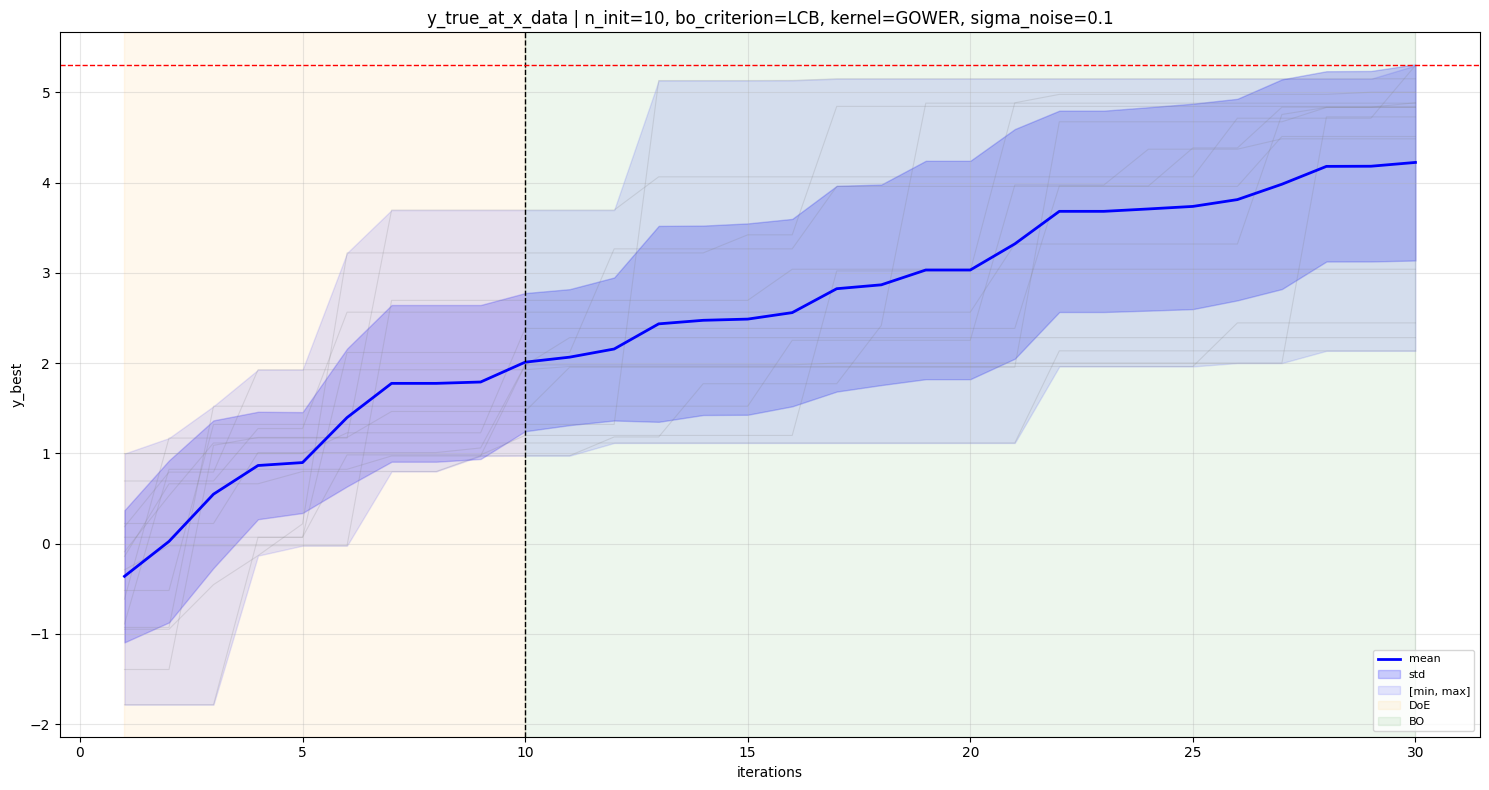

In [ ]:
plot_convergence_curve(
    results=res,
    metric="y_true_at_x_data",
    filters={"n_init": 10, "bo_criterion": "LCB", "kernel": "GOWER", "sigma_noise": 0.1},
    figsize=(15,8)
)

### **Boxplots convergence_iter_bo group by n_init.**

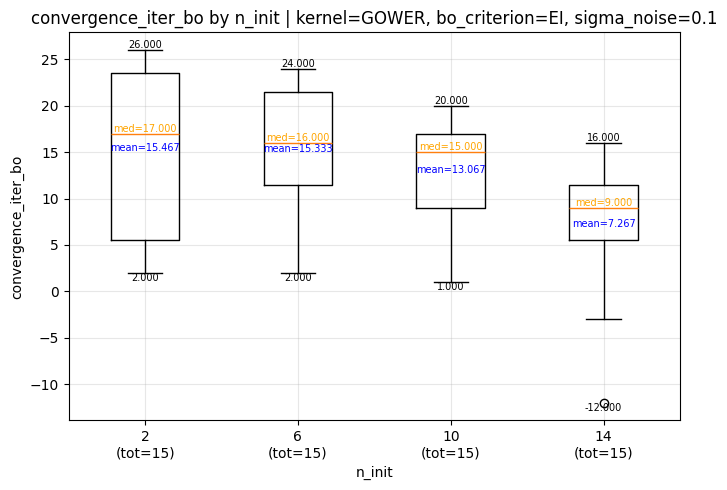

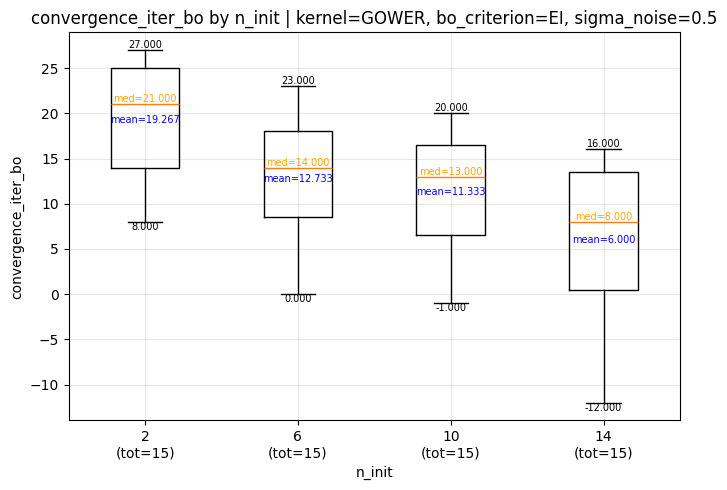

No results found after filter was applied.


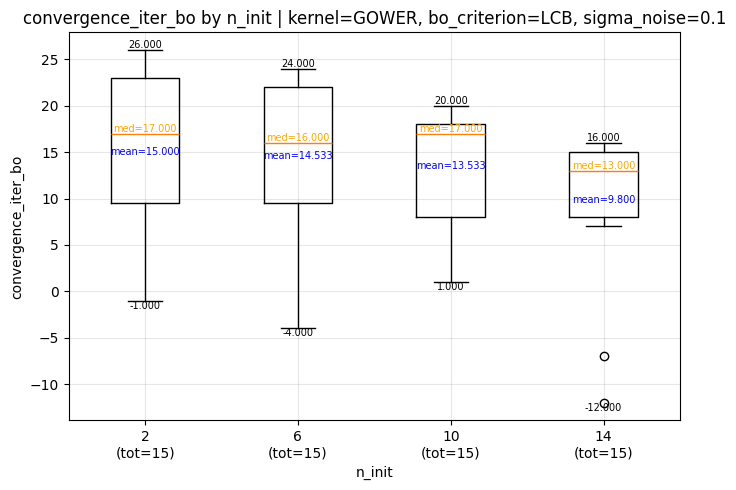

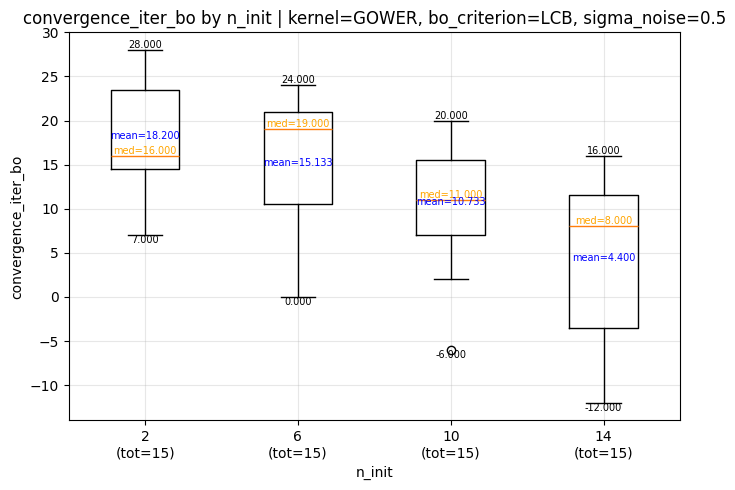

No results found after filter was applied.


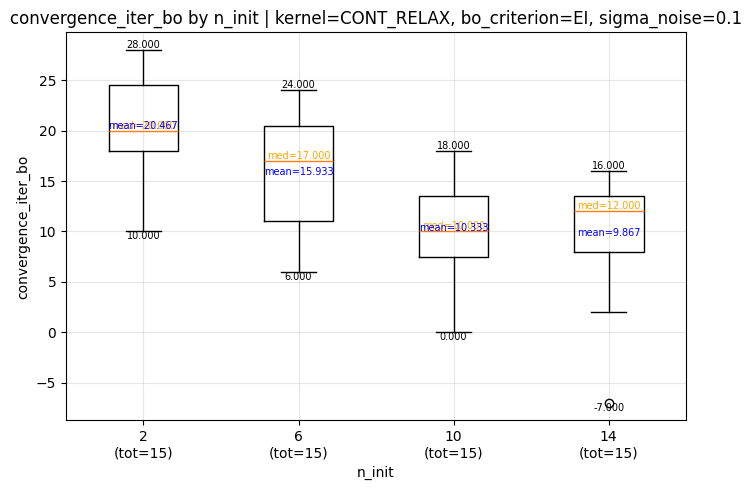

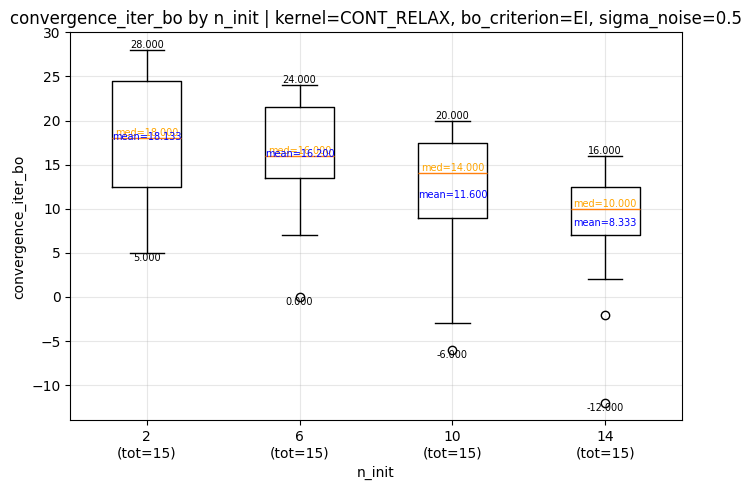

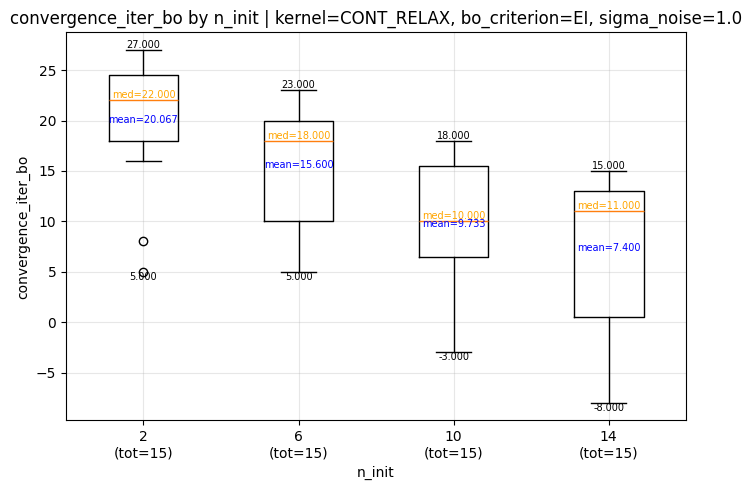

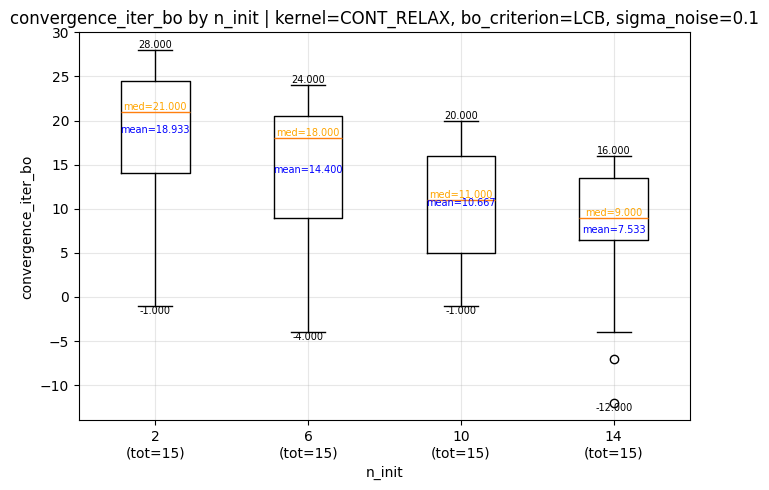

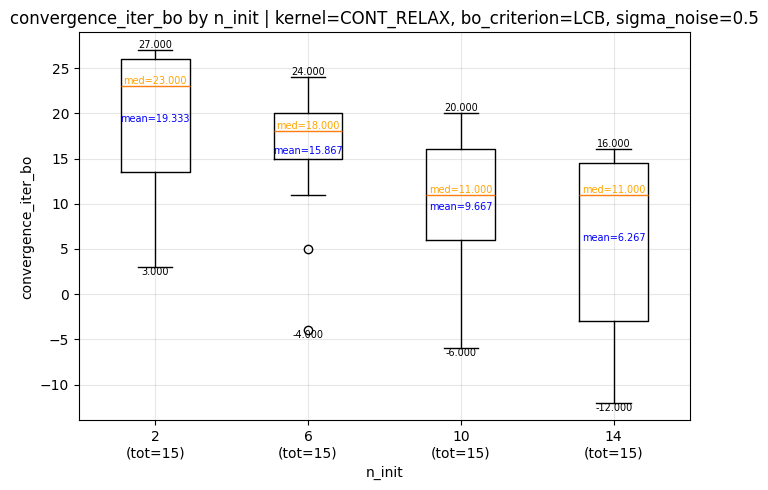

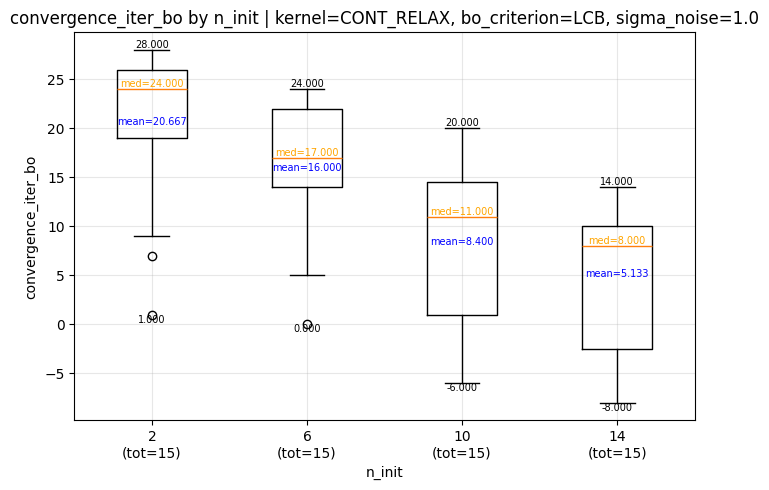

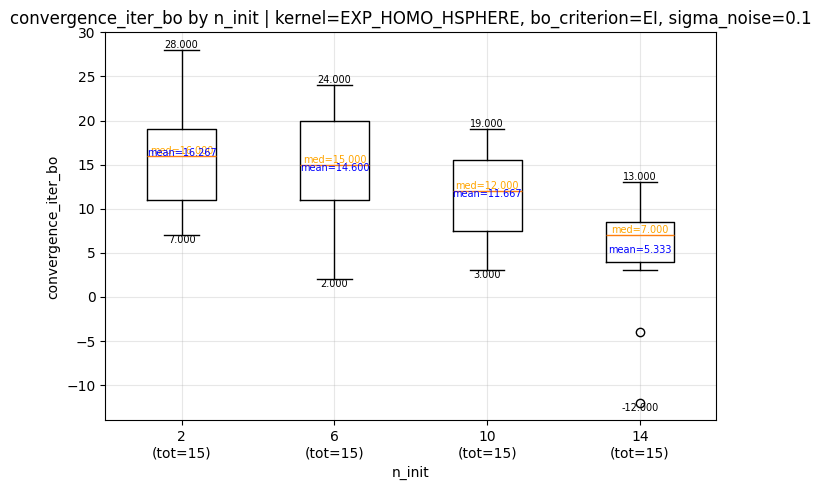

No results found after filter was applied.


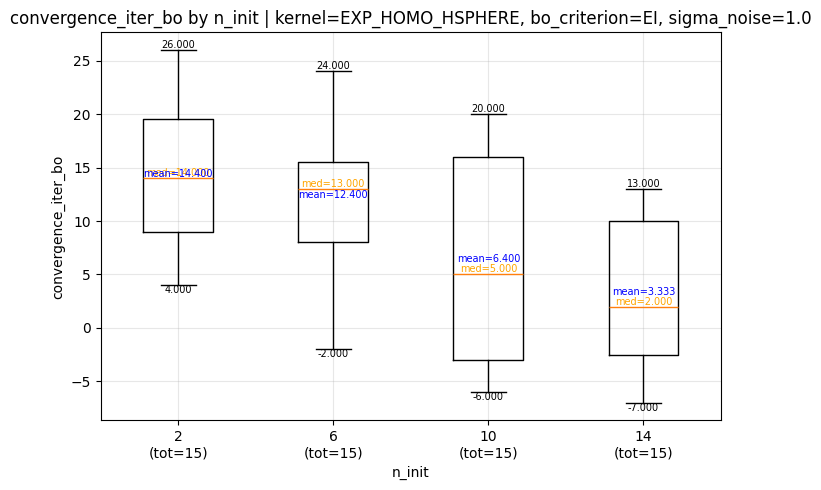

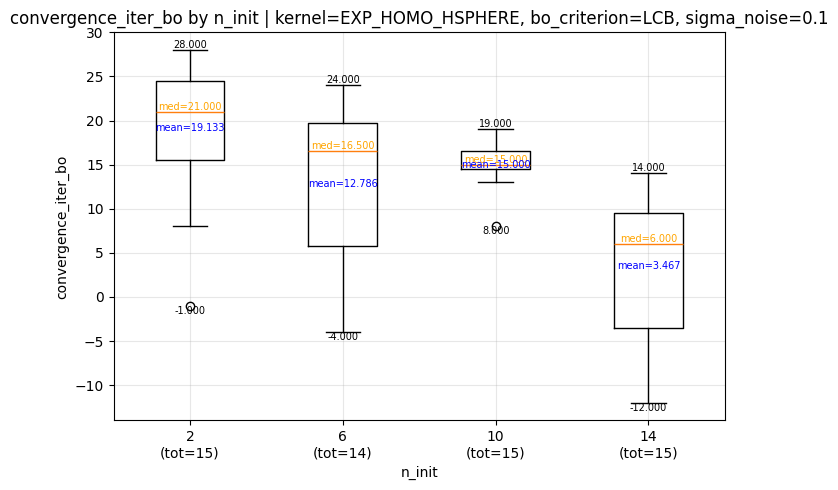

No results found after filter was applied.


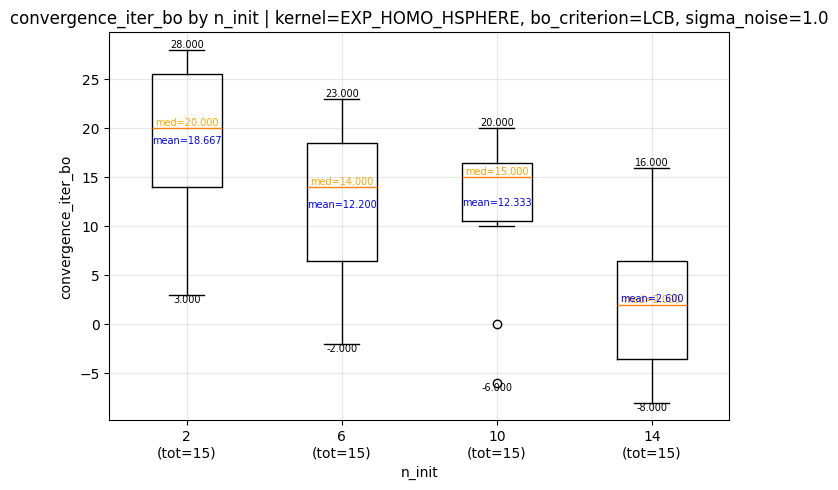

In [ ]:
for kernel in ["GOWER", "CONT_RELAX", "EXP_HOMO_HSPHERE"]:
    for bo_criterion in ["EI", "LCB"]:
        for sigma_noise in [0.1, 0.5, 1.0]:
            plot_boxplot(
                results=res,
                metric="convergence_iter_bo",
                group_by="n_init",
                filters={
                    "kernel": kernel,
                    "bo_criterion": bo_criterion,
                    "sigma_noise": sigma_noise,
                },
            )

### **Boxplots y group by n_init.**

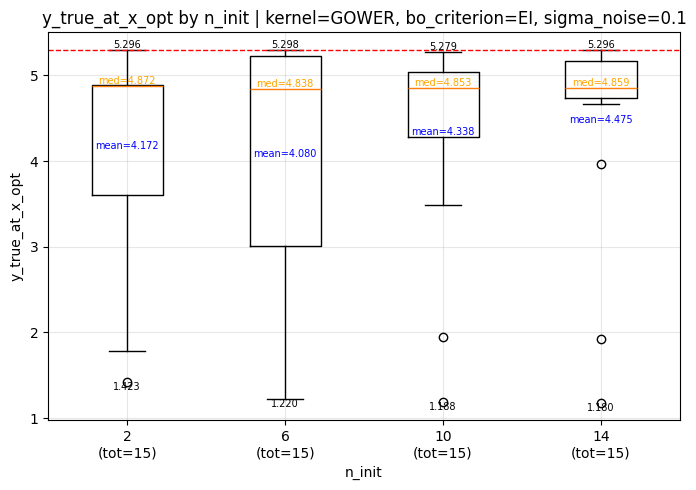

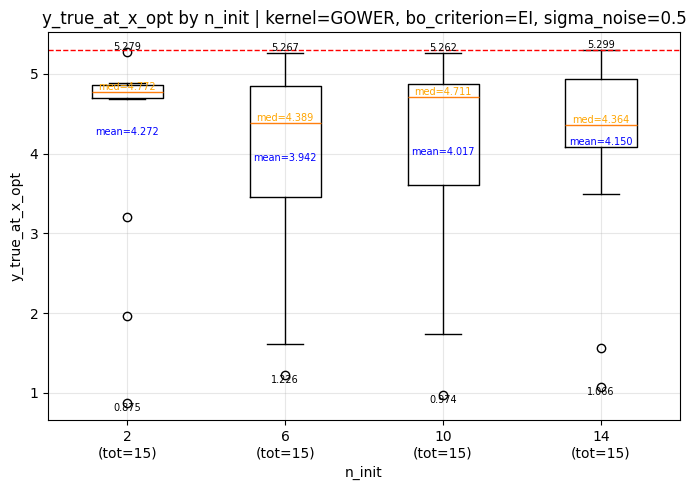

No results found after filter was applied.


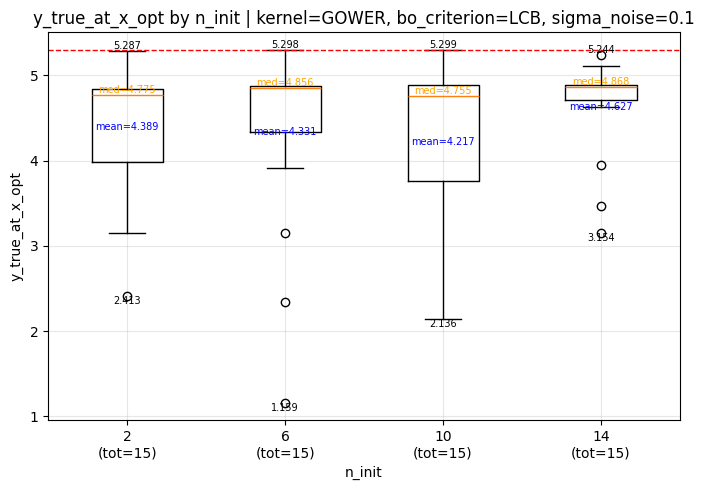

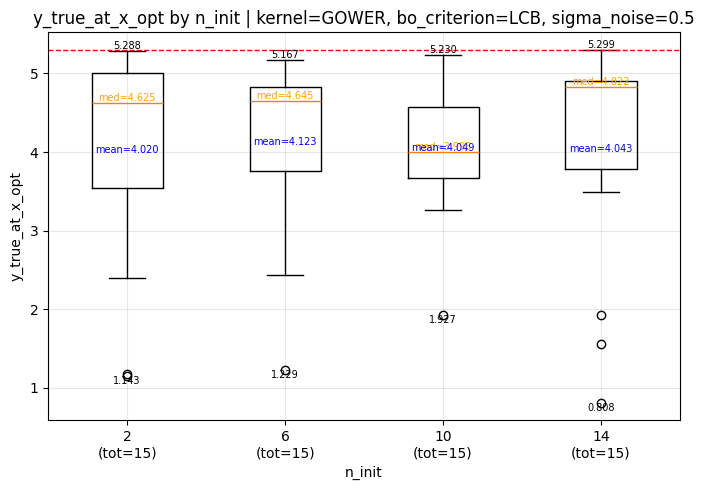

No results found after filter was applied.


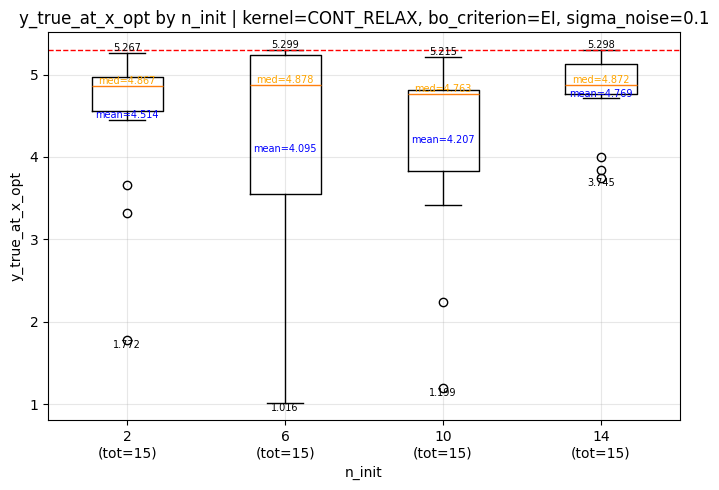

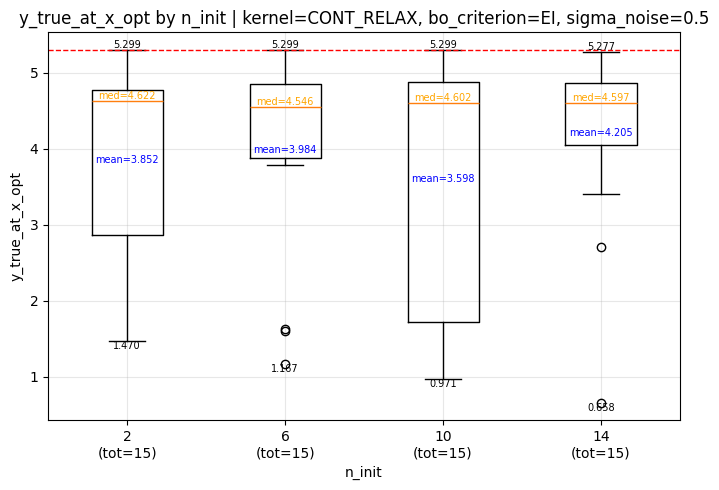

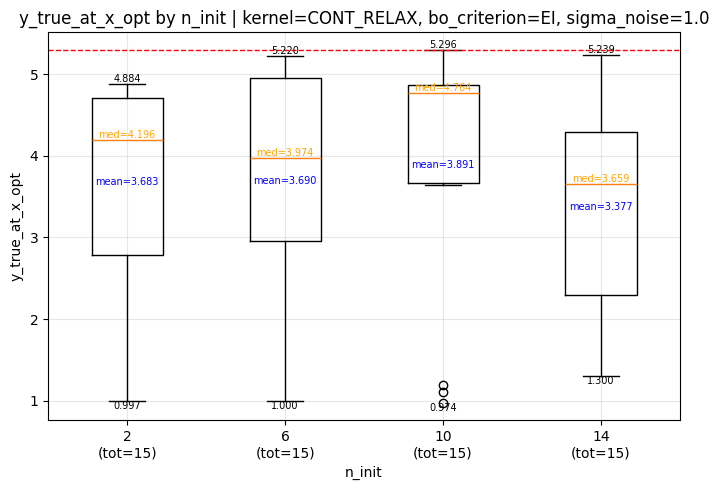

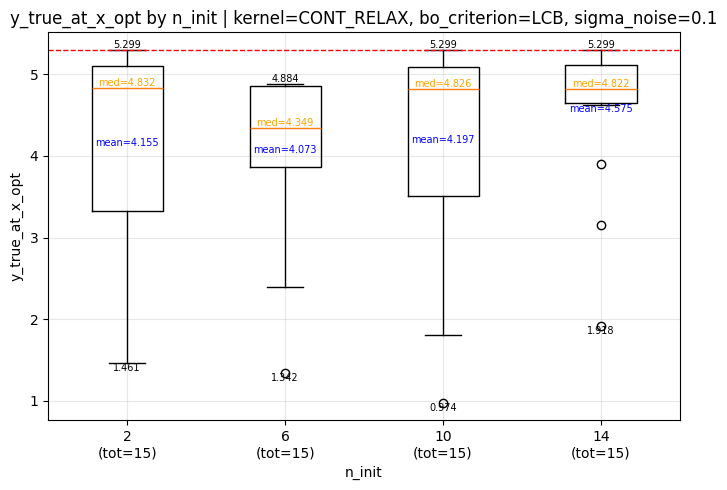

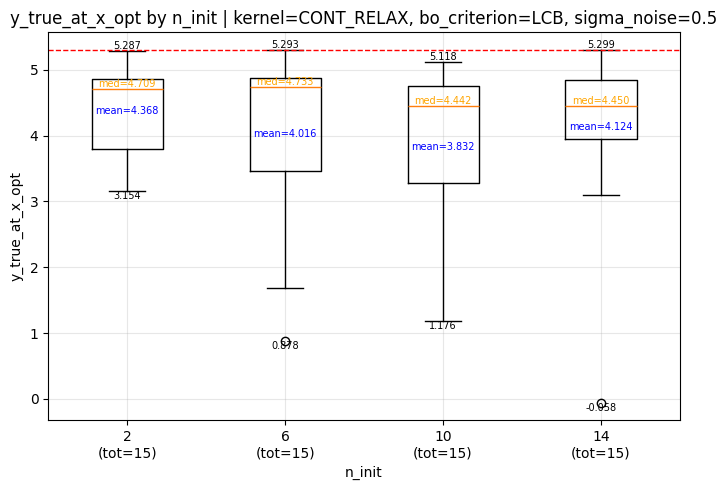

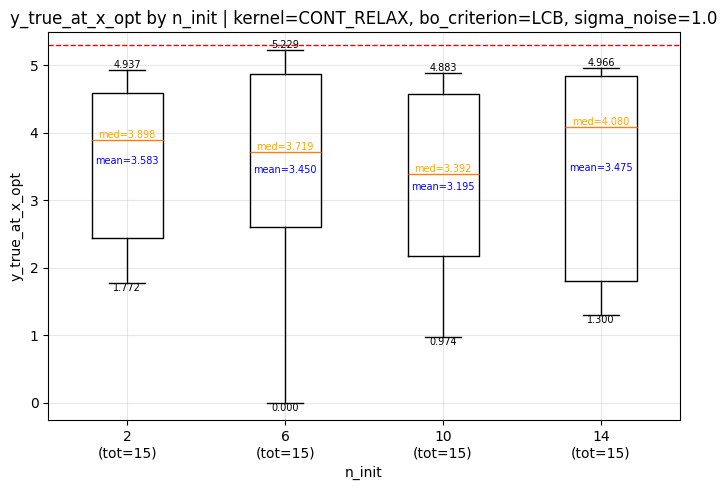

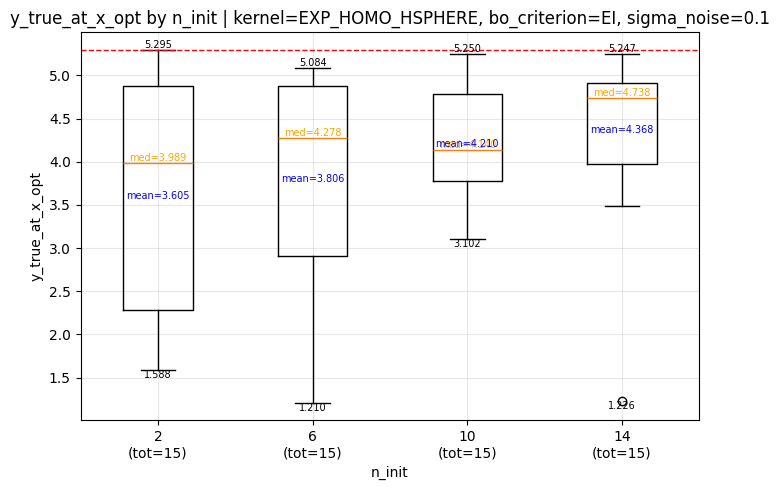

No results found after filter was applied.


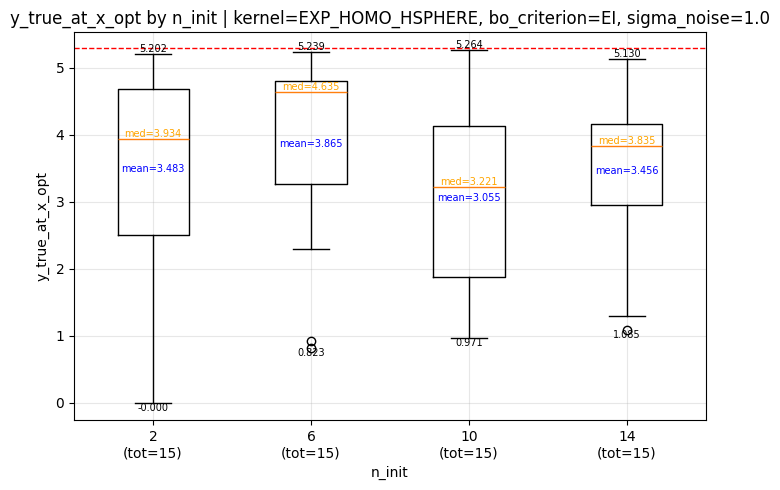

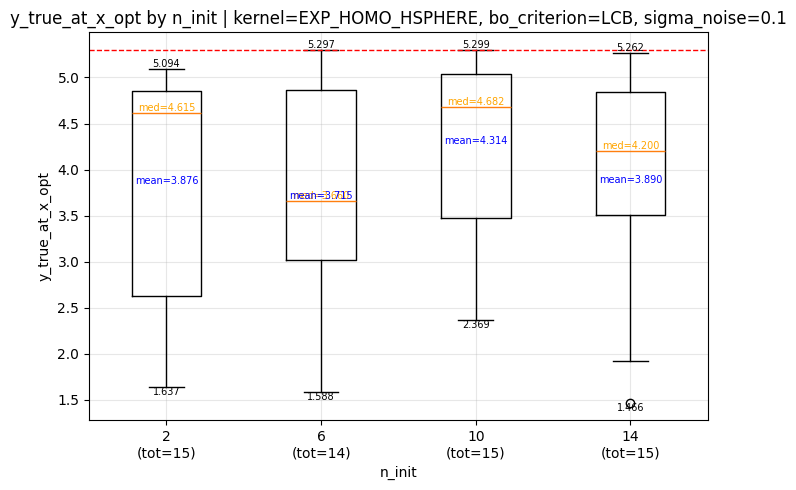

No results found after filter was applied.


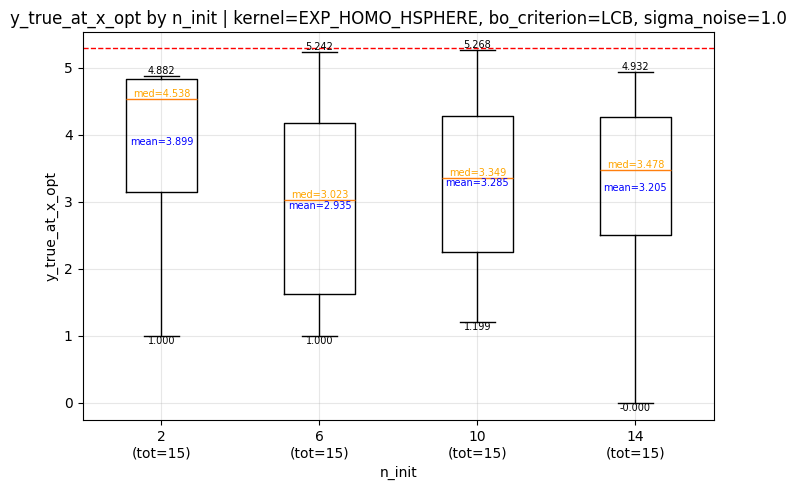

In [ ]:
for kernel in ["GOWER", "CONT_RELAX", "EXP_HOMO_HSPHERE"]:
    for bo_criterion in ["EI", "LCB"]:
        for sigma_noise in [0.1, 0.5, 1.0]:
            plot_boxplot(
                results=res,
                metric="y_true_at_x_opt",
                group_by="n_init",
                filters={
                    "kernel": kernel,
                    "bo_criterion": bo_criterion,
                    "sigma_noise": sigma_noise,
                },
            )

In [ ]:
#for kernel in ["GOWER", "CONT_RELAX", "EXP_HOMO_HSPHERE"]:
    #for bo_criterion in ["EI", "LCB"]:
for sigma_noise in [0.1, 0.5, 1.0]:
    plot_boxplot(
        results=res,
        metric="y_true_at_x_opt",
        group_by="n_init",
        filters={
            #"kernel": kernel,
            #"bo_criterion": bo_criterion,
            "sigma_noise": sigma_noise,
        },
    )

### **Boxplots y group by bo_criterion.**

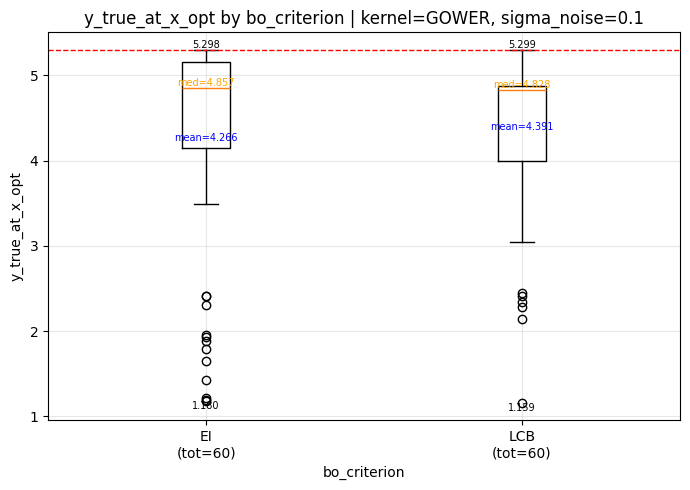

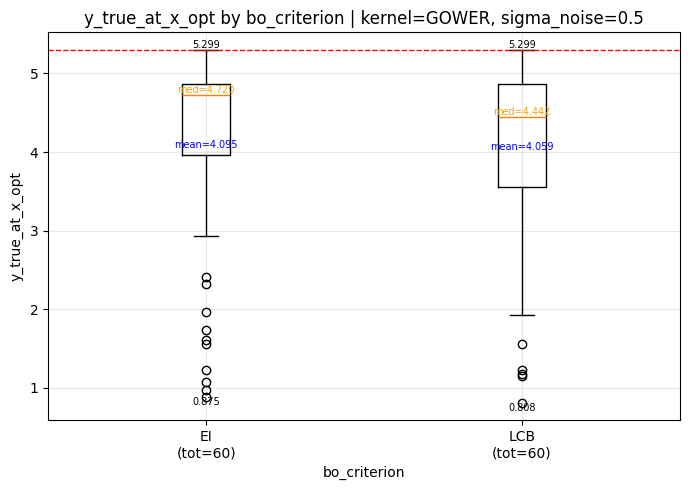

No results found after filter was applied.


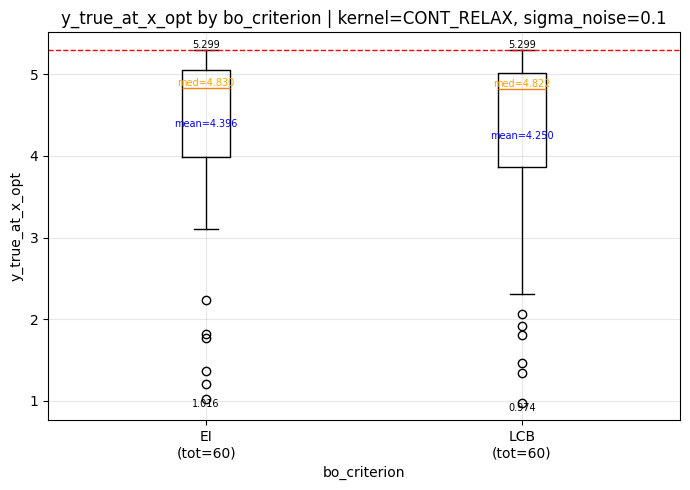

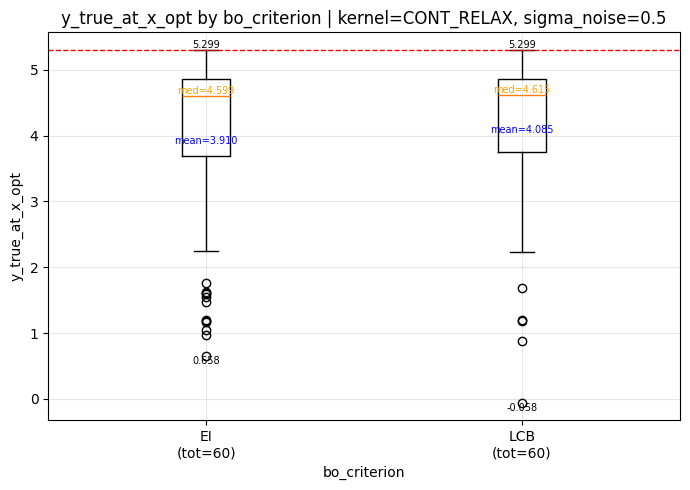

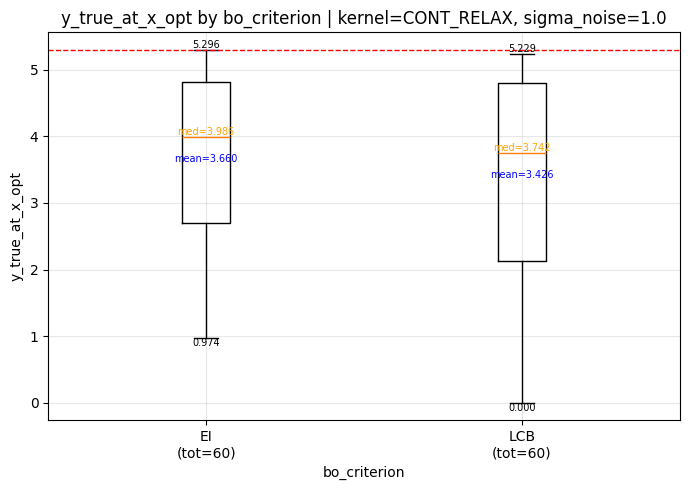

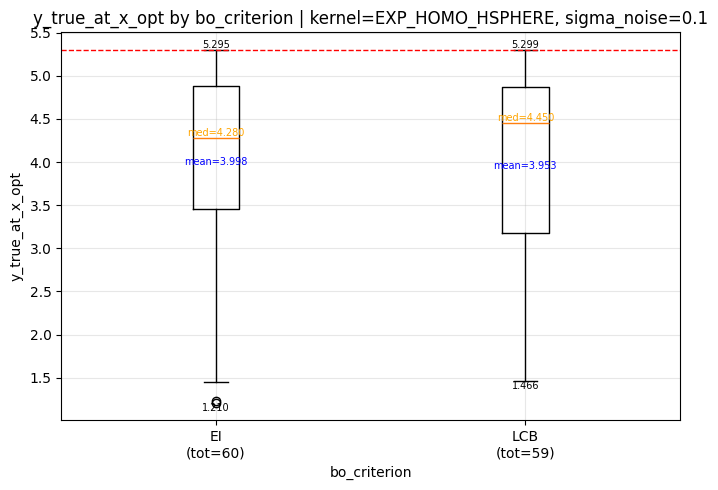

No results found after filter was applied.


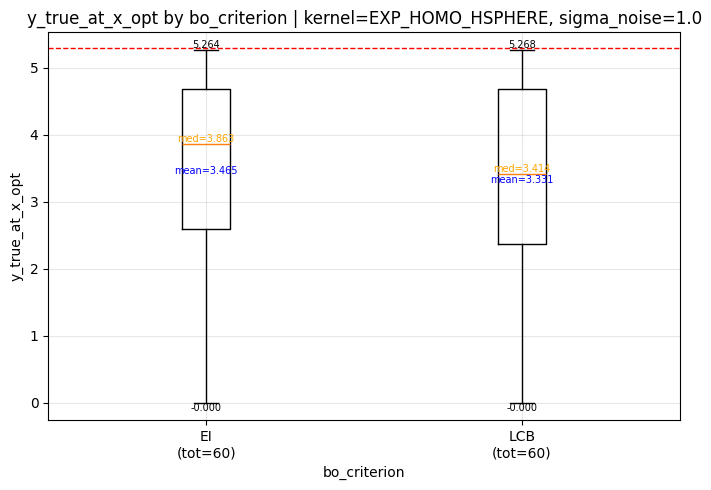

In [ ]:
# y group by bo_criterion
for kernel in ["GOWER", "CONT_RELAX", "EXP_HOMO_HSPHERE"]:
    for sigma_noise in [0.1, 0.5, 1.0]:
        plot_boxplot(
            results=res,
            metric="y_true_at_x_opt",
            group_by="bo_criterion",
            filters={
                "kernel": kernel,
                "sigma_noise": sigma_noise,
            },
        )

### **Boxplots y group by kernel.**

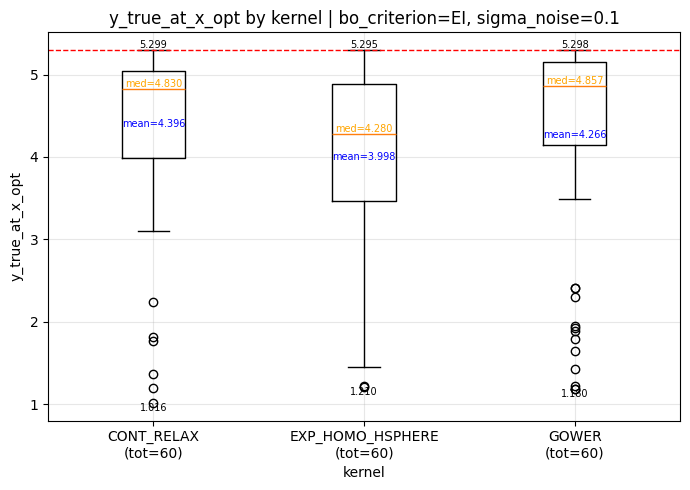

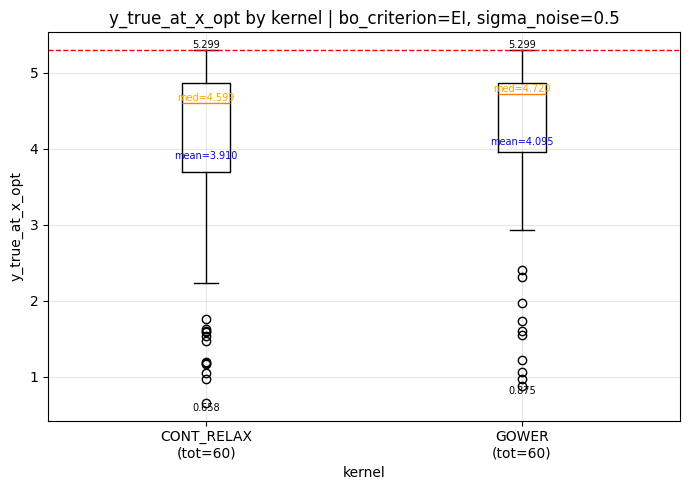

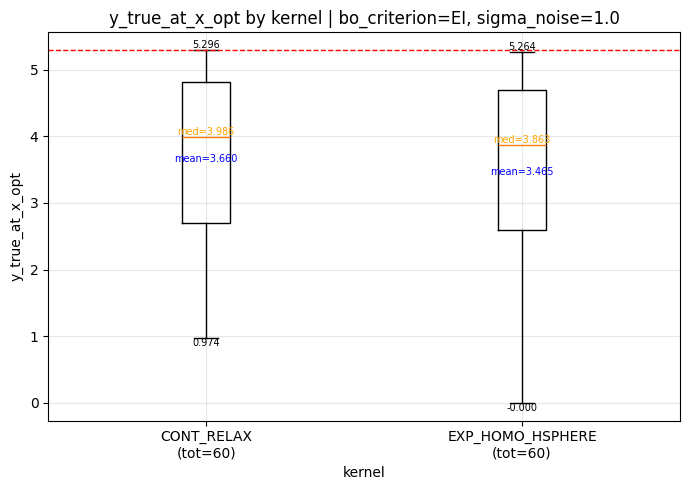

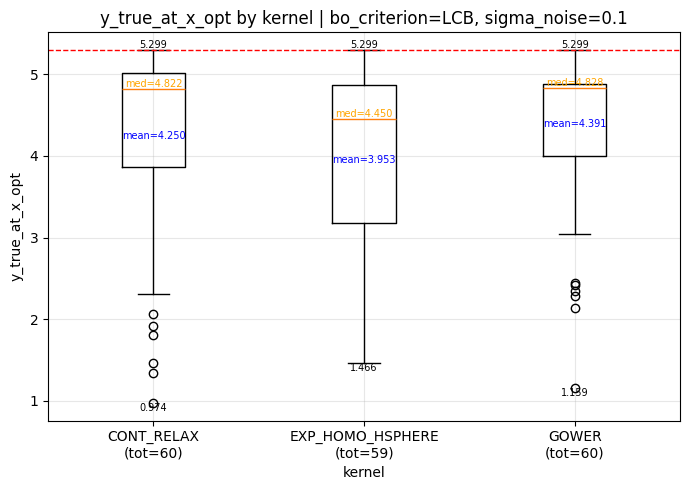

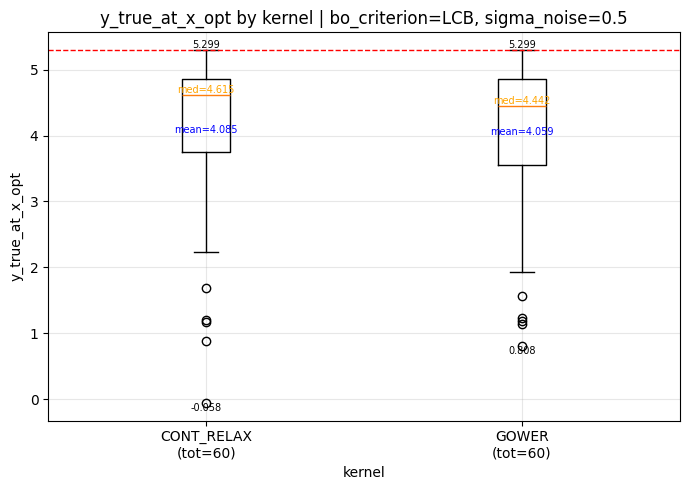

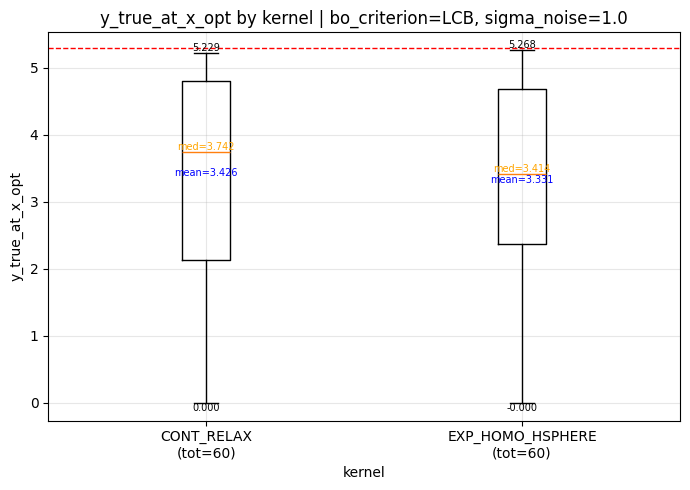

In [ ]:
# y group by kernel
for bo_criterion in ["EI", "LCB"]:
    for sigma_noise in [0.1, 0.5, 1.0]:
        plot_boxplot(
            results=res,
            metric="y_true_at_x_opt",
            group_by="kernel",
            filters={
                "bo_criterion": bo_criterion,
                "sigma_noise": sigma_noise,
            },
        )